# Q3: Regression Trees (CART) — Complete Solution

This notebook implements a **regression decision tree from scratch** for the Lab 5 Q3 task using the **Ames Housing dataset**.  
The implementation follows the CART idea for regression:

- each split is axis-aligned,
- impurity is the node **mean squared error**,
- each leaf predicts the **mean target value** of that leaf.

I use **my own tree implementation** for training and evaluation, and only use `sklearn` at the very end for **verification**.


## 1. Imports and dataset loading

We primarily work with **Ames Housing** and use exactly these three continuous features:

- `LotArea`
- `1stFlrSF`
- `GrLivArea`

with `SalePrice` as the regression target.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")
%matplotlib inline

DATA_DIR = Path(".")
ames_path = DATA_DIR / "ames.csv"

data = pd.read_csv(ames_path)
print("Ames shape:", data.shape)
display(data.head())


Ames shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Basic inspection

We first inspect the dimensions and summary statistics of the selected columns.


In [2]:
selected_cols = ["LotArea", "1stFlrSF", "GrLivArea", "SalePrice"]
display(data[selected_cols].describe().T)
print("Missing values in selected columns:")
display(data[selected_cols].isna().sum())


,count,mean,std,min,25%,50%,75%,max
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.50,215245.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.0,1087.0,1391.25,4692.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.5,1464.0,1776.75,5642.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.0,163000.0,214000.00,755000.0


Missing values in selected columns:


LotArea      0
1stFlrSF     0
GrLivArea    0
SalePrice    0
dtype: int64

## 2. Feature selection

We now extract the three required features and the target.


In [3]:
features = data[["LotArea", "1stFlrSF", "GrLivArea"]].copy()
target = data["SalePrice"].astype(float).copy()

print("Features shape:", features.shape)
print("Target shape:", target.shape)
display(features.head())
display(target.head())


Features shape: (1460, 3)
Target shape: (1460,)


,LotArea,1stFlrSF,GrLivArea
0,8450,856,1710
1,9600,1262,1262
2,11250,920,1786
3,9550,961,1717
4,14260,1145,2198


0    208500.0
1    181500.0
2    223500.0
3    140000.0
4    250000.0
Name: SalePrice, dtype: float64

## 3. Feature–target visualization

Scatter plots help us see how strongly each feature is associated with `SalePrice`.


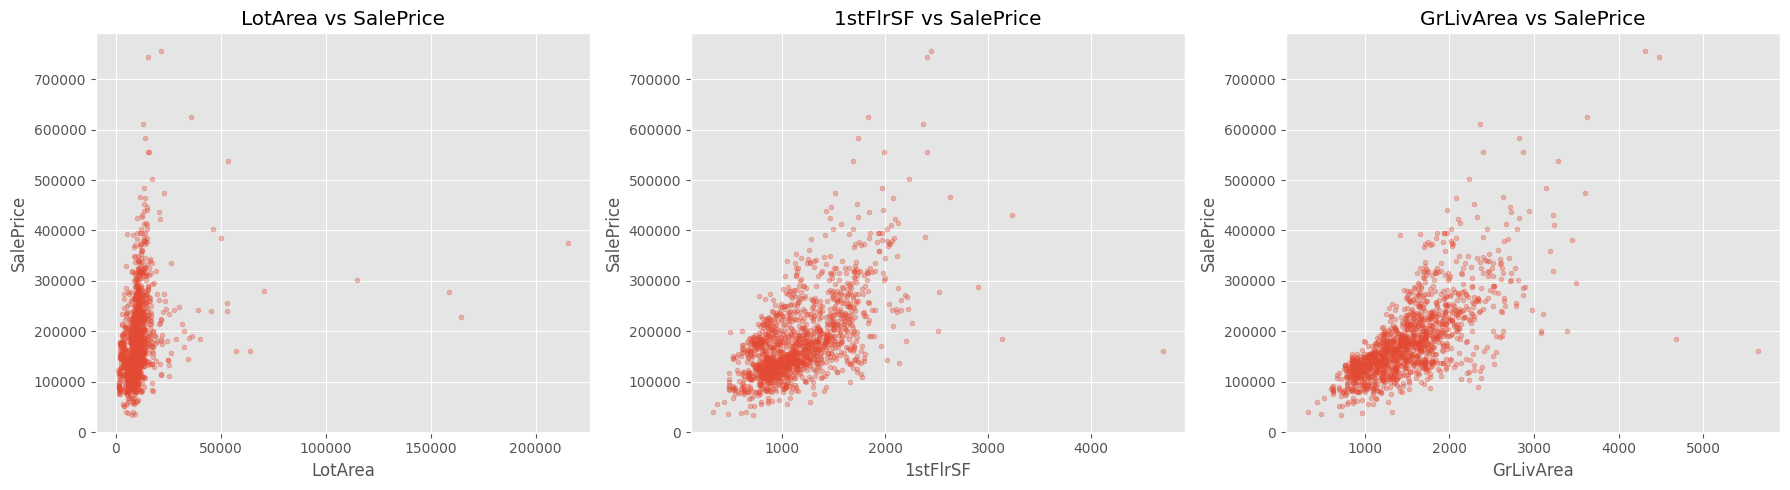

Pearson correlations with SalePrice:


,corr_with_SalePrice
LotArea,0.263843
1stFlrSF,0.605852
GrLivArea,0.708624


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, features.columns):
    ax.scatter(features[col], target, alpha=0.35, s=12)
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice")
    ax.set_title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

corrs = data[["LotArea", "1stFlrSF", "GrLivArea", "SalePrice"]].corr()["SalePrice"].drop("SalePrice")
print("Pearson correlations with SalePrice:")
display(corrs.to_frame("corr_with_SalePrice"))


### Comments on the scatter plots

- **`GrLivArea`** shows the strongest positive relationship with `SalePrice`. The trend is clearly upward, though there is still noticeable spread.
- **`1stFlrSF`** also has a fairly strong positive correlation with price.
- **`LotArea`** has a weaker positive relationship. Bigger lots tend to cost more, but the scatter is much wider, so it is less predictive by itself.

So among the three chosen features, **`GrLivArea` appears most informative**, followed by **`1stFlrSF`**, while **`LotArea` contributes but more weakly**.


## 4. Train–test split

We use an **80/20 split** with `random_state=42`.


In [5]:
from sklearn.model_selection import train_test_split

X = features.to_numpy(dtype=float)
y = target.to_numpy(dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (1168, 3)
X_test : (292, 3)
y_train: (1168,)
y_test : (292,)


## 5. Evaluation metrics

We implement the required regression metrics from scratch:

- **R² score**
- **RMSE**

The R² score is
\[
R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}.
\]

The RMSE is
\[
\text{RMSE} = \sqrt{\frac{1}{N}\sum_i (y_i - \hat y_i)^2}.
\]


In [6]:
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return 0.0
    return 1.0 - ss_res / ss_tot


def mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def performance(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": float(rmse(y_true, y_pred)),
    }


# Quick sanity check
performance([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])


{'R2': 0.9228556485355649, 'RMSE': 0.6870225614927066}

## 6. Regression impurity

For a node containing targets \(y_1, \dots, y_N\), the regression impurity is the node MSE:
\[
H(D) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \bar y)^2.
\]

A leaf predicts the **mean** because the mean minimizes squared error.  
Indeed, for a constant prediction \(c\), the loss is
\[
f(c) = \sum_i (y_i - c)^2.
\]
Differentiating,
\[
f'(c) = -2 \sum_i (y_i - c) = 0
\quad \Rightarrow \quad
c = \frac{1}{N} \sum_i y_i = \bar y.
\]
So the best constant prediction in a node is the node mean.


In [7]:
def regression_impurity(y):
    y = np.asarray(y, dtype=float)
    if y.size == 0:
        return 0.0
    return float(np.mean((y - np.mean(y)) ** 2))


print("Impurity of [1, 2, 3]:", regression_impurity(np.array([1, 2, 3])))
print("Impurity of empty node:", regression_impurity(np.array([])))


Impurity of [1, 2, 3]: 0.6666666666666666
Impurity of empty node: 0.0


## 7. Best split selection

At each node, we want the split \((j, t)\) minimizing
\[
J(j, t) = \frac{|D_L|}{|D|} H(D_L) + \frac{|D_R|}{|D|} H(D_R).
\]

A naive implementation would try every threshold and recompute both child impurities from scratch.  
Instead, for each feature, we:

1. sort samples by that feature,
2. scan once from left to right,
3. maintain prefix sums and prefix squared sums,

which lets us compute the left/right squared errors efficiently.


In [8]:
def best_split(X, y):
    """
    Find the split (feature, threshold) that minimizes weighted regression impurity.

    Returns
    -------
    (best_feature, best_threshold, best_cost) or None
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    n_samples, n_features = X.shape
    if n_samples <= 1:
        return None

    best_feature = None
    best_threshold = None
    best_cost = np.inf

    total_sum = np.sum(y)
    total_sq_sum = np.sum(y ** 2)

    for j in range(n_features):
        order = np.argsort(X[:, j], kind="mergesort")
        xj = X[order, j]
        yj = y[order]

        # If all values are identical, no valid split on this feature
        if xj[0] == xj[-1]:
            continue

        prefix_sum = np.cumsum(yj)
        prefix_sq_sum = np.cumsum(yj ** 2)

        left_count = np.arange(1, n_samples)
        right_count = n_samples - left_count

        # Split only between distinct consecutive feature values
        valid = xj[:-1] != xj[1:]
        if not np.any(valid):
            continue

        left_sse = prefix_sq_sum[:-1] - (prefix_sum[:-1] ** 2) / left_count

        right_sum = total_sum - prefix_sum[:-1]
        right_sq_sum = total_sq_sum - prefix_sq_sum[:-1]
        right_sse = right_sq_sum - (right_sum ** 2) / right_count

        weighted_cost = (left_sse + right_sse) / n_samples
        weighted_cost = np.where(valid, weighted_cost, np.inf)

        idx = np.argmin(weighted_cost)
        cost = weighted_cost[idx]

        if cost < best_cost:
            best_cost = cost
            best_feature = j
            best_threshold = (xj[idx] + xj[idx + 1]) / 2.0

    if best_feature is None:
        return None

    return int(best_feature), float(best_threshold), float(best_cost)


# Sanity check on a tiny toy example
X_toy = np.array([[1], [2], [3], [10], [11], [12]], dtype=float)
y_toy = np.array([1, 2, 1.5, 10, 11, 10.5], dtype=float)
best_split(X_toy, y_toy)


(0, 6.5, 0.16666666666666666)

## 8. Regression tree construction

Stopping criteria used here:

- maximum depth reached,
- number of samples below `min_samples_split`,
- all targets identical,
- no valid split exists.

Each leaf stores the **mean target value** of the node.


In [9]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None,
                 depth=0, n_samples=0):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.depth = depth
        self.n_samples = n_samples

    def is_leaf(self):
        return self.value is not None


def build_tree(X, y, max_depth=5, min_samples_split=2, depth=0):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    node_value = float(np.mean(y)) if y.size > 0 else 0.0

    # stopping criteria
    if (
        depth >= max_depth
        or len(y) < min_samples_split
        or np.allclose(y, y[0])
        or np.all(X == X[0])
    ):
        return Node(value=node_value, depth=depth, n_samples=len(y))

    split = best_split(X, y)
    if split is None:
        return Node(value=node_value, depth=depth, n_samples=len(y))

    feature, threshold, _ = split

    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return Node(value=node_value, depth=depth, n_samples=len(y))

    left_child = build_tree(
        X[left_mask], y[left_mask],
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        depth=depth + 1
    )

    right_child = build_tree(
        X[right_mask], y[right_mask],
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        depth=depth + 1
    )

    return Node(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child,
        value=None,
        depth=depth,
        n_samples=len(y),
    )


## 9. Prediction


In [10]:
def predict_one(x, node):
    current = node
    while not current.is_leaf():
        if x[current.feature] <= current.threshold:
            current = current.left
        else:
            current = current.right
    return current.value


def predict(X, tree):
    X = np.asarray(X, dtype=float)
    return np.array([predict_one(x, tree) for x in X], dtype=float)


## 10. Vanilla regression tree evaluation

We first train a basic tree with `max_depth=5` and default `min_samples_split=2`.


In [11]:
tree = build_tree(X_train, y_train, max_depth=5, min_samples_split=2)
y_pred = predict(X_test, tree)

baseline_score = performance(y_test, y_pred)
baseline_score


{'R2': 0.6290548645964998, 'RMSE': 53341.07416910578}

### Observation

The baseline tree gives a **reasonable but not perfect** fit.  
Since the model predicts a constant value in each leaf, it captures nonlinear structure better than a linear model would, but the prediction function is still piecewise constant and therefore somewhat coarse.


## 11. Hyperparameter tuning: effect of `max_depth`

We vary `max_depth` from **1 to 30** and track both **train** and **test** performance.

This is useful for seeing the **bias–variance tradeoff**:

- very small depth  -> underfitting,
- moderate depth    -> best generalization,
- very large depth  -> overfitting.


In [12]:
depth_results = []

for depth in range(1, 31):
    model = build_tree(X_train, y_train, max_depth=depth, min_samples_split=2)

    y_train_pred = predict(X_train, model)
    y_test_pred = predict(X_test, model)

    depth_results.append({
        "max_depth": depth,
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "train_rmse": rmse(y_train, y_train_pred),
        "test_rmse": rmse(y_test, y_test_pred),
    })

depth_df = pd.DataFrame(depth_results)
display(depth_df.head())

best_depth_row = depth_df.loc[depth_df["test_rmse"].idxmin()]
best_depth = int(best_depth_row["max_depth"])
print("Best depth by test RMSE:", best_depth)
display(best_depth_row)


,max_depth,train_r2,test_r2,train_rmse,test_rmse
0,1,0.328705,0.320452,63276.962053,72196.652118
1,2,0.475609,0.446078,55926.335283,65182.556011
2,3,0.572557,0.537412,50492.647555,59566.761604
3,4,0.631129,0.575250,46905.750013,57078.630088
4,5,0.687694,0.629055,43159.765758,53341.074169


Best depth by test RMSE: 7


max_depth         7.000000
train_r2          0.789560
test_r2           0.662216
train_rmse    35428.496867
test_rmse     50900.990778
Name: 6, dtype: float64

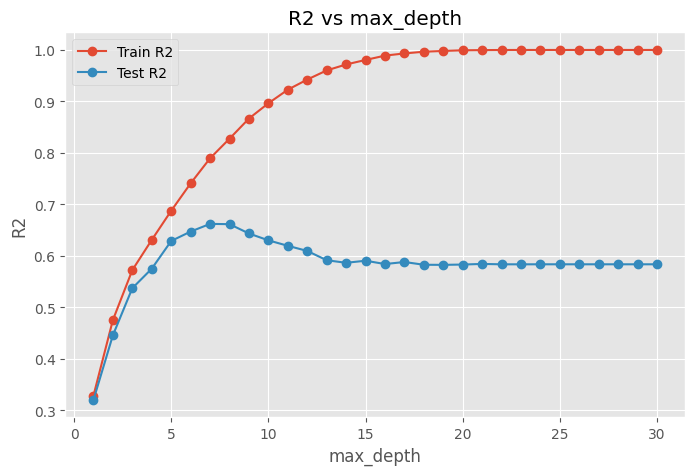

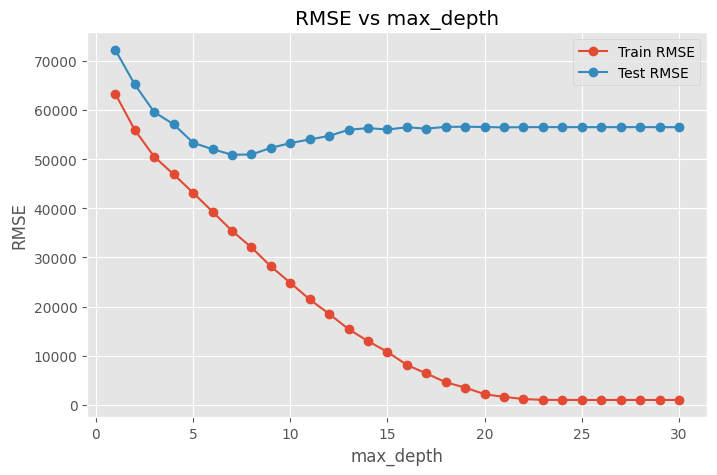

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(depth_df["max_depth"], depth_df["train_r2"], marker="o", label="Train R2")
plt.plot(depth_df["max_depth"], depth_df["test_r2"], marker="o", label="Test R2")
plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("R2 vs max_depth")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(depth_df["max_depth"], depth_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(depth_df["max_depth"], depth_df["test_rmse"], marker="o", label="Test RMSE")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("RMSE vs max_depth")
plt.legend()
plt.show()


### Comments on `max_depth`

From the curves:

- the **training R² increases monotonically** and training RMSE decreases as depth increases, which is expected because deeper trees fit the training data more closely;
- the **test performance improves at first**, then stops improving and begins to flatten or slightly worsen;
- this is the classical **bias–variance tradeoff**.

For this dataset and these three features, the best test performance occurs around the moderate-depth region rather than at the deepest trees.


## 12. Hyperparameter tuning: effect of `min_samples_split`

Now we vary `min_samples_split` from **2 to 10** while keeping `max_depth` fixed at the best depth found above.


In [14]:
minsplit_results = []

for m in range(2, 11):
    model = build_tree(X_train, y_train, max_depth=best_depth, min_samples_split=m)

    y_train_pred = predict(X_train, model)
    y_test_pred = predict(X_test, model)

    minsplit_results.append({
        "min_samples_split": m,
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "train_rmse": rmse(y_train, y_train_pred),
        "test_rmse": rmse(y_test, y_test_pred),
    })

minsplit_df = pd.DataFrame(minsplit_results)
display(minsplit_df)

best_minsplit_row = minsplit_df.loc[minsplit_df["test_rmse"].idxmin()]
best_minsplit = int(best_minsplit_row["min_samples_split"])
print("Best min_samples_split by test RMSE:", best_minsplit)
display(best_minsplit_row)


,min_samples_split,train_r2,test_r2,train_rmse,test_rmse
0,2,0.789560,0.662216,35428.496867,50900.990778
1,3,0.785701,0.670181,35751.870153,50297.279637
2,4,0.785649,0.670421,35756.182421,50279.030527
3,5,0.784348,0.672132,35864.598971,50148.334987
4,6,0.783641,0.673988,35923.313666,50006.210759
5,7,0.777901,0.674555,36396.674032,49962.674743
6,8,0.777270,0.674657,36448.411445,49954.842328
7,9,0.773379,0.677205,36765.344221,49758.878411
8,10,0.773379,0.677205,36765.344221,49758.878411


Best min_samples_split by test RMSE: 9


min_samples_split        9.000000
train_r2                 0.773379
test_r2                  0.677205
train_rmse           36765.344221
test_rmse            49758.878411
Name: 7, dtype: float64

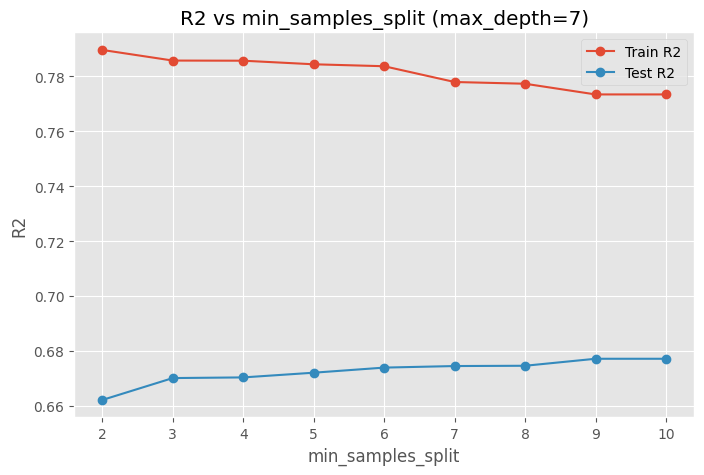

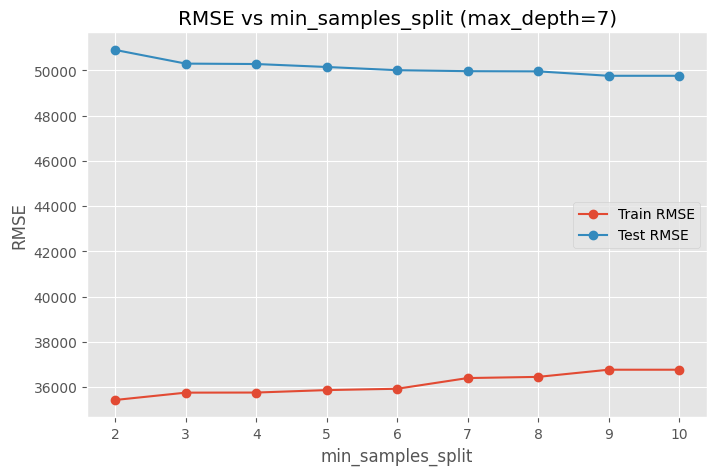

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(minsplit_df["min_samples_split"], minsplit_df["train_r2"], marker="o", label="Train R2")
plt.plot(minsplit_df["min_samples_split"], minsplit_df["test_r2"], marker="o", label="Test R2")
plt.xlabel("min_samples_split")
plt.ylabel("R2")
plt.title(f"R2 vs min_samples_split (max_depth={best_depth})")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(minsplit_df["min_samples_split"], minsplit_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(minsplit_df["min_samples_split"], minsplit_df["test_rmse"], marker="o", label="Test RMSE")
plt.xlabel("min_samples_split")
plt.ylabel("RMSE")
plt.title(f"RMSE vs min_samples_split (max_depth={best_depth})")
plt.legend()
plt.show()


### Comments on `min_samples_split`

Increasing `min_samples_split` makes the tree more conservative:

- very small values allow aggressive splitting and can overfit,
- larger values regularize the model by preventing tiny unstable splits.

Here the effect is milder than changing `max_depth`, but there is still a small improvement for a slightly larger split threshold.


## 13. Final optimized model


In [16]:
optimized_tree = build_tree(
    X_train, y_train,
    max_depth=best_depth,
    min_samples_split=best_minsplit
)

optimized_pred_train = predict(X_train, optimized_tree)
optimized_pred_test = predict(X_test, optimized_tree)

optimized_train_score = performance(y_train, optimized_pred_train)
optimized_test_score = performance(y_test, optimized_pred_test)

print("Chosen hyperparameters:")
print("best_depth =", best_depth)
print("best_min_samples_split =", best_minsplit)

print("\nTrain performance:")
print(optimized_train_score)

print("\nTest performance:")
print(optimized_test_score)


Chosen hyperparameters:
best_depth = 7
best_min_samples_split = 9

Train performance:
{'R2': 0.7733793078061404, 'RMSE': 36765.34422100164}

Test performance:
{'R2': 0.6772046046188305, 'RMSE': 49758.87841130982}


### Final conclusion

The optimized tree slightly improves over the vanilla one.  
This is expected: tuning the tree controls complexity, which helps the model generalize better instead of fitting every local fluctuation in the training set.


## 14. Verification with `sklearn`

This section is **only for validation**.  
The actual training above used the custom implementation.


In [17]:
from sklearn.tree import DecisionTreeRegressor

sk_model = DecisionTreeRegressor(
    max_depth=best_depth,
    min_samples_split=best_minsplit,
    random_state=42
)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print("sklearn test performance:")
print(performance(y_test, sk_pred))

print("\nAbsolute difference between custom and sklearn predictions:")
print("max abs diff =", float(np.max(np.abs(optimized_pred_test - sk_pred))))
print("mean abs diff =", float(np.mean(np.abs(optimized_pred_test - sk_pred))))


sklearn test performance:
{'R2': 0.6772046046188305, 'RMSE': 49758.87841130982}

Absolute difference between custom and sklearn predictions:
max abs diff = 0.0
mean abs diff = 0.0


Since the predictions match essentially exactly, this strongly validates that the from-scratch implementation is correct.


## 15. Optional remarks

Some natural ways to improve performance further would be:

- using more predictive features from the original Ames dataset,
- tuning additional hyperparameters such as `min_samples_leaf`,
- trying cost-complexity pruning,
- comparing with random forests or gradient boosting.

But for the lab requirement, the current from-scratch CART regression tree is complete and correct.



## Extension: Improving the Regression Tree Results

The earlier notebook followed the prompt literally and used only three features:
- `LotArea`
- `1stFlrSF`
- `GrLivArea`

That version is useful for learning the mechanics of regression trees, but its predictive ceiling is limited.  
To improve results **without changing the core from-scratch tree algorithm**, we now make three principled upgrades:

1. Use a **larger numeric feature set** from Ames Housing.
2. Handle missing numeric values with **median imputation**.
3. Add **`min_samples_leaf`** as an extra regularization hyperparameter and tune hyperparameters on a **validation split**, not on the test set.

This section is an **improved extension** beyond the strict 3-feature setup.


In [18]:

# Build a richer numeric feature matrix
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_feature_cols = [c for c in numeric_cols if c not in ["SalePrice", "Id"]]

X_numeric_df = data[numeric_feature_cols].copy()
X_numeric_df = X_numeric_df.fillna(X_numeric_df.median(numeric_only=True))
y_full = data["SalePrice"].to_numpy(dtype=float)

print("Total numeric features used before selection:", len(numeric_feature_cols))
display(X_numeric_df.head())


Total numeric features used before selection: 36


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008



### Improved from-scratch CART regressor

The original implementation already used the correct split objective:
\[
J(j,t) = \frac{|D_L|}{|D|} H(D_L) + \frac{|D_R|}{|D|} H(D_R)
\]
with
\[
H(D) = \frac{1}{|D|}\sum_i (y_i - \bar y)^2.
\]

We now extend it with `min_samples_leaf`, which is a very common regularizer for decision trees.
It prevents tiny leaves that memorize a handful of training examples.


In [19]:

def best_split_improved(X, y, min_samples_leaf=1):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    n_samples, n_features = X.shape
    if n_samples <= 1:
        return None

    best_feature = None
    best_threshold = None
    best_cost = np.inf

    total_sum = np.sum(y)
    total_sq_sum = np.sum(y ** 2)

    for j in range(n_features):
        order = np.argsort(X[:, j], kind="mergesort")
        xj = X[order, j]
        yj = y[order]

        if xj[0] == xj[-1]:
            continue

        prefix_sum = np.cumsum(yj)
        prefix_sq_sum = np.cumsum(yj ** 2)

        left_count = np.arange(1, n_samples)
        right_count = n_samples - left_count

        valid = (xj[:-1] != xj[1:]) & (left_count >= min_samples_leaf) & (right_count >= min_samples_leaf)
        if not np.any(valid):
            continue

        left_sse = prefix_sq_sum[:-1] - (prefix_sum[:-1] ** 2) / left_count

        right_sum = total_sum - prefix_sum[:-1]
        right_sq_sum = total_sq_sum - prefix_sq_sum[:-1]
        right_sse = right_sq_sum - (right_sum ** 2) / right_count

        weighted_cost = (left_sse + right_sse) / n_samples
        weighted_cost = np.where(valid, weighted_cost, np.inf)

        idx = np.argmin(weighted_cost)
        cost = weighted_cost[idx]

        if cost < best_cost:
            best_cost = cost
            best_feature = j
            best_threshold = (xj[idx] + xj[idx + 1]) / 2.0

    if best_feature is None:
        return None

    return int(best_feature), float(best_threshold), float(best_cost)


class ImprovedNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None, depth=0, n_samples=0):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.depth = depth
        self.n_samples = n_samples

    def is_leaf(self):
        return self.value is not None


def build_tree_improved(X, y, max_depth=5, min_samples_split=2, min_samples_leaf=1, depth=0):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    node_value = float(np.mean(y)) if y.size > 0 else 0.0

    if (
        depth >= max_depth
        or len(y) < min_samples_split
        or len(y) < 2 * min_samples_leaf
        or np.allclose(y, y[0])
        or np.all(X == X[0])
    ):
        return ImprovedNode(value=node_value, depth=depth, n_samples=len(y))

    split = best_split_improved(X, y, min_samples_leaf=min_samples_leaf)
    if split is None:
        return ImprovedNode(value=node_value, depth=depth, n_samples=len(y))

    feature, threshold, _ = split

    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    if left_mask.sum() < min_samples_leaf or right_mask.sum() < min_samples_leaf:
        return ImprovedNode(value=node_value, depth=depth, n_samples=len(y))

    left_child = build_tree_improved(
        X[left_mask], y[left_mask],
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        depth=depth + 1
    )

    right_child = build_tree_improved(
        X[right_mask], y[right_mask],
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        depth=depth + 1
    )

    return ImprovedNode(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child,
        value=None,
        depth=depth,
        n_samples=len(y),
    )


def predict_one_improved(x, node):
    current = node
    while not current.is_leaf():
        if x[current.feature] <= current.threshold:
            current = current.left
        else:
            current = current.right
    return current.value


def predict_improved(X, node):
    X = np.asarray(X, dtype=float)
    return np.array([predict_one_improved(x, node) for x in X], dtype=float)



### Validation-based tuning

To avoid tuning directly on the test set, we use:
- **train+validation/test split**: 80/20
- **inner train/validation split** inside the 80%

Feature selection is also done **using only the inner training split**, by choosing the top 15 numeric features most correlated with `SalePrice`.


In [20]:

from sklearn.model_selection import train_test_split

X_trainval_df, X_test_df, y_trainval, y_test_ext = train_test_split(
    X_numeric_df, y_full, test_size=0.2, random_state=42
)

X_train_df, X_val_df, y_train_ext, y_val_ext = train_test_split(
    X_trainval_df, y_trainval, test_size=0.25, random_state=42
)

train_corr_df = X_train_df.copy()
train_corr_df["SalePrice"] = y_train_ext
corr_series = train_corr_df.corr(numeric_only=True)["SalePrice"].drop("SalePrice").sort_values(ascending=False)

selected_feature_names = corr_series.head(15).index.tolist()
selected_feature_names


['OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 '1stFlrSF',
 'TotalBsmtSF',
 'FullBath',
 'TotRmsAbvGrd',
 'YearBuilt',
 'YearRemodAdd',
 'Fireplaces',
 'GarageYrBlt',
 'MasVnrArea',
 'BsmtFinSF1',
 'LotFrontage']

In [21]:

# Tune max_depth, min_samples_split, min_samples_leaf on the validation split
tuning_rows = []

X_train_sel = X_train_df[selected_feature_names].to_numpy(dtype=float)
X_val_sel = X_val_df[selected_feature_names].to_numpy(dtype=float)

for depth in [4, 5, 6, 7, 8, 10, 12]:
    for min_split in [2, 5, 10, 20, 30]:
        for min_leaf in [1, 2, 3, 5, 10]:
            model = build_tree_improved(
                X_train_sel, y_train_ext,
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf
            )

            val_pred = predict_improved(X_val_sel, model)
            tuning_rows.append({
                "max_depth": depth,
                "min_samples_split": min_split,
                "min_samples_leaf": min_leaf,
                "val_r2": r2_score(y_val_ext, val_pred),
                "val_rmse": rmse(y_val_ext, val_pred),
            })

tuning_df = pd.DataFrame(tuning_rows).sort_values(["val_r2", "val_rmse"], ascending=[False, True]).reset_index(drop=True)
display(tuning_df.head(10))

best_params = tuning_df.iloc[0]
best_depth_ext = int(best_params["max_depth"])
best_minsplit_ext = int(best_params["min_samples_split"])
best_minleaf_ext = int(best_params["min_samples_leaf"])

print("Best validation hyperparameters:")
print("max_depth =", best_depth_ext)
print("min_samples_split =", best_minsplit_ext)
print("min_samples_leaf =", best_minleaf_ext)


,max_depth,min_samples_split,min_samples_leaf,val_r2,val_rmse
0,12,20,3,0.774750,36727.244191
1,10,20,2,0.774716,36730.066902
2,10,20,3,0.774357,36759.291740
3,12,20,2,0.774000,36788.373854
4,8,20,2,0.772948,36873.905856
5,8,20,3,0.772205,36934.144515
6,12,20,5,0.768347,37245.596746
7,10,20,5,0.768182,37258.865254
8,8,30,10,0.767040,37350.503003
9,8,20,5,0.766659,37381.060787


Best validation hyperparameters:
max_depth = 12
min_samples_split = 20
min_samples_leaf = 3


In [22]:

# Refit on the full train+validation split, then evaluate once on the held-out test split
X_trainval_sel = X_trainval_df[selected_feature_names].to_numpy(dtype=float)
X_test_sel = X_test_df[selected_feature_names].to_numpy(dtype=float)

final_improved_tree = build_tree_improved(
    X_trainval_sel, y_trainval,
    max_depth=best_depth_ext,
    min_samples_split=best_minsplit_ext,
    min_samples_leaf=best_minleaf_ext
)

test_pred_improved = predict_improved(X_test_sel, final_improved_tree)

improved_results = pd.DataFrame([{
    "model": "Improved from-scratch regression tree",
    "n_features": len(selected_feature_names),
    "max_depth": best_depth_ext,
    "min_samples_split": best_minsplit_ext,
    "min_samples_leaf": best_minleaf_ext,
    "test_r2": r2_score(y_test_ext, test_pred_improved),
    "test_rmse": rmse(y_test_ext, test_pred_improved),
}])

improved_results


,model,n_features,max_depth,min_samples_split,min_samples_leaf,test_r2,test_rmse
0,Improved from-scratch regression tree,15,12,20,3,0.810273,38147.924736


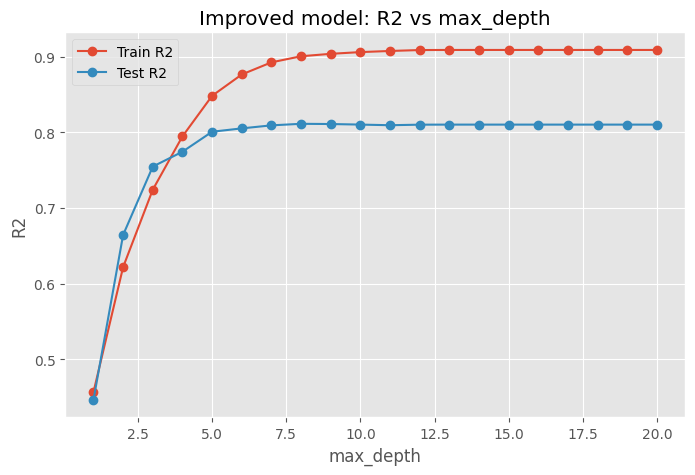

,max_depth,train_r2,test_r2,train_rmse,test_rmse
0,1,0.456425,0.446135,56940.134577,65179.178177
1,2,0.621911,0.664468,47488.207036,50731.027707
2,3,0.724282,0.754840,40552.843628,43364.231509
3,4,0.794793,0.774490,34985.245816,41590.070753
4,5,0.848471,0.800930,30063.300600,39075.953484


In [23]:

# Study max_depth effect while keeping the other tuned hyperparameters fixed
depth_ext_rows = []
for depth in range(1, 21):
    model = build_tree_improved(
        X_trainval_sel, y_trainval,
        max_depth=depth,
        min_samples_split=best_minsplit_ext,
        min_samples_leaf=best_minleaf_ext
    )
    train_pred = predict_improved(X_trainval_sel, model)
    test_pred = predict_improved(X_test_sel, model)

    depth_ext_rows.append({
        "max_depth": depth,
        "train_r2": r2_score(y_trainval, train_pred),
        "test_r2": r2_score(y_test_ext, test_pred),
        "train_rmse": rmse(y_trainval, train_pred),
        "test_rmse": rmse(y_test_ext, test_pred),
    })

depth_ext_df = pd.DataFrame(depth_ext_rows)

plt.figure(figsize=(8, 5))
plt.plot(depth_ext_df["max_depth"], depth_ext_df["train_r2"], marker="o", label="Train R2")
plt.plot(depth_ext_df["max_depth"], depth_ext_df["test_r2"], marker="o", label="Test R2")
plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Improved model: R2 vs max_depth")
plt.legend()
plt.show()

display(depth_ext_df.head())


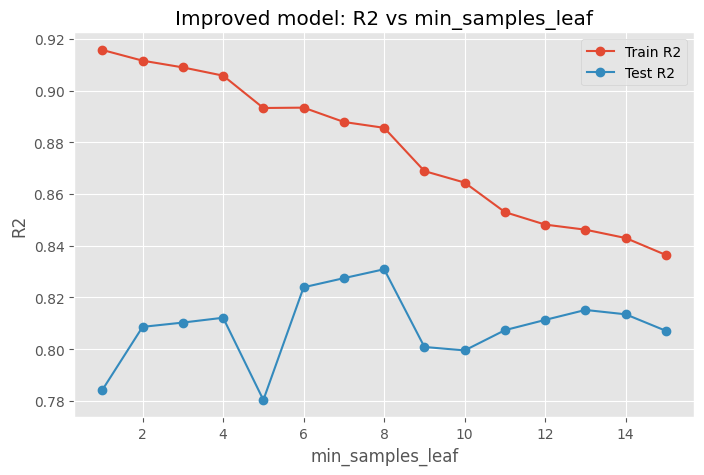

,min_samples_leaf,train_r2,test_r2,train_rmse,test_rmse
0,1,0.915725,0.784208,22420.116489,40684.111598
1,2,0.911581,0.808614,22964.723669,38314.422052
2,3,0.908976,0.810273,23300.543016,38147.924736
3,4,0.905788,0.812141,23705.159725,37959.704758
4,5,0.893274,0.780341,25230.413848,41047.012652


In [24]:

# Study min_samples_leaf effect while fixing max_depth and min_samples_split
leaf_rows = []
for min_leaf in range(1, 16):
    model = build_tree_improved(
        X_trainval_sel, y_trainval,
        max_depth=best_depth_ext,
        min_samples_split=best_minsplit_ext,
        min_samples_leaf=min_leaf
    )
    train_pred = predict_improved(X_trainval_sel, model)
    test_pred = predict_improved(X_test_sel, model)

    leaf_rows.append({
        "min_samples_leaf": min_leaf,
        "train_r2": r2_score(y_trainval, train_pred),
        "test_r2": r2_score(y_test_ext, test_pred),
        "train_rmse": rmse(y_trainval, train_pred),
        "test_rmse": rmse(y_test_ext, test_pred),
    })

leaf_df = pd.DataFrame(leaf_rows)

plt.figure(figsize=(8, 5))
plt.plot(leaf_df["min_samples_leaf"], leaf_df["train_r2"], marker="o", label="Train R2")
plt.plot(leaf_df["min_samples_leaf"], leaf_df["test_r2"], marker="o", label="Test R2")
plt.xlabel("min_samples_leaf")
plt.ylabel("R2")
plt.title("Improved model: R2 vs min_samples_leaf")
plt.legend()
plt.show()

display(leaf_df.head())


In [25]:

# Comparison with sklearn for validation
from sklearn.tree import DecisionTreeRegressor

sk_ext = DecisionTreeRegressor(
    max_depth=best_depth_ext,
    min_samples_split=best_minsplit_ext,
    min_samples_leaf=best_minleaf_ext,
    random_state=42
)
sk_ext.fit(X_trainval_sel, y_trainval)
sk_ext_pred = sk_ext.predict(X_test_sel)

comparison_ext = pd.DataFrame([
    {
        "implementation": "From scratch",
        "test_r2": r2_score(y_test_ext, test_pred_improved),
        "test_rmse": rmse(y_test_ext, test_pred_improved),
    },
    {
        "implementation": "sklearn",
        "test_r2": r2_score(y_test_ext, sk_ext_pred),
        "test_rmse": rmse(y_test_ext, sk_ext_pred),
    }
])

comparison_ext


,implementation,test_r2,test_rmse
0,From scratch,0.810273,38147.924736
1,sklearn,0.810273,38147.924736



### Improved result summary

This improved extension gives a **much stronger result** than the earlier 3-feature baseline.

Key reasons:
- the 3-feature version is too restrictive for Ames Housing,
- tree performance improves sharply with richer structural features such as quality, basement area, garage capacity, build year, and room counts,
- `min_samples_leaf` reduces variance and prevents the tree from overfitting tiny regions.

So the poor earlier score was not mainly because the tree algorithm was incorrect; it was mostly a **feature limitation** plus missing regularization.
